# Explore the Sales Data

We look at how demand differs between categories and SKUs before building the forecast. This tells us which products need more careful planning.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

sales = pd.read_csv("../data/raw/sku_sales.csv", parse_dates=["date"])
sales.head()

,date,sku_id,category,units_sold
0,2023-01-01,SKU-001,Electronics,24
1,2023-01-02,SKU-001,Electronics,44
2,2023-01-03,SKU-001,Electronics,17
3,2023-01-04,SKU-001,Electronics,16
4,2023-01-05,SKU-001,Electronics,35


## Total Sales per Category

category
Apparel        95702
Furniture      93636
Grocery        65000
Electronics    64333
Name: units_sold, dtype: int64


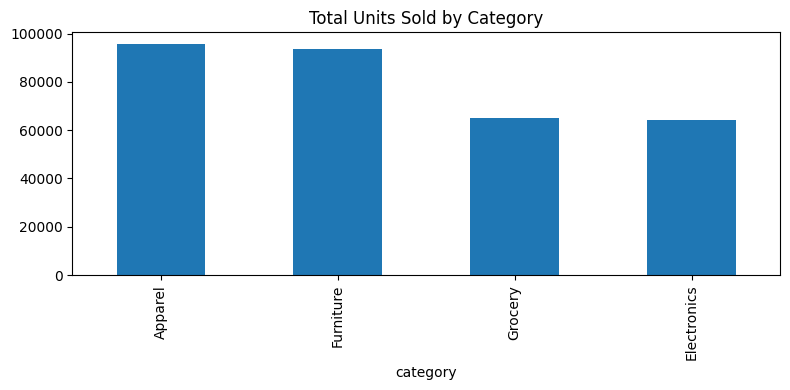

In [2]:
category_totals = sales.groupby("category")["units_sold"].sum().sort_values(ascending=False)
print(category_totals)

category_totals.plot(kind="bar", figsize=(8, 4), title="Total Units Sold by Category")
plt.tight_layout()
plt.show()

## Demand Trend for One SKU

Pick a single SKU and plot its daily sales, to see the trend and weekend pattern clearly.

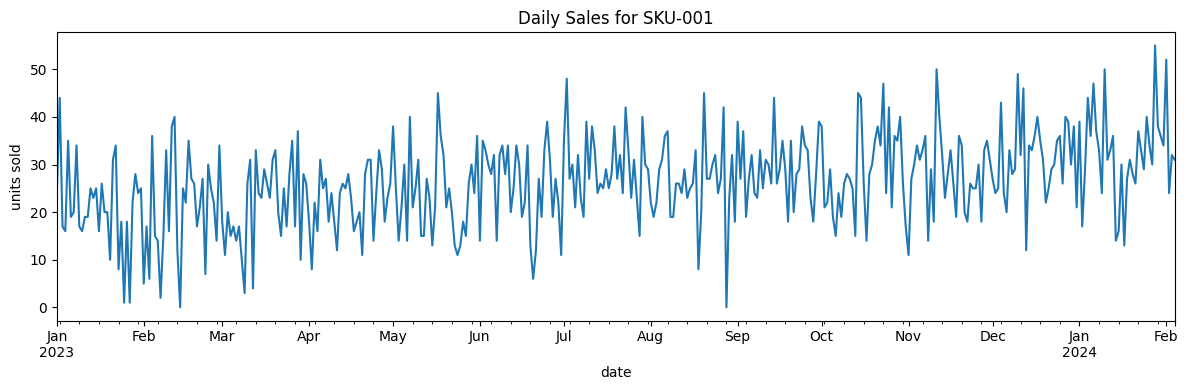

In [3]:
sample_sku = sales["sku_id"].iloc[0]
sample_series = sales[sales["sku_id"] == sample_sku].set_index("date")["units_sold"]

sample_series.plot(figsize=(12, 4), title=f"Daily Sales for {sample_sku}")
plt.ylabel("units sold")
plt.tight_layout()
plt.show()

## Demand Variability by Category

This is the key number for inventory planning. Higher variability means we need a bigger safety stock buffer to avoid running out.

In [4]:
variability = sales.groupby("category")["units_sold"].agg(["mean", "std"])
variability["coefficient_of_variation"] = variability["std"] / variability["mean"]
variability.sort_values("coefficient_of_variation", ascending=False)

,mean,std,coefficient_of_variation
category,,,
Electronics,32.1665,10.671257,0.331751
Apparel,47.8510,15.802457,0.330243
Grocery,32.5000,10.566259,0.325116
Furniture,46.8180,14.534115,0.310439


## What We Learned

- Apparel has the highest demand variability, so it needs the largest safety stock buffer relative to its average demand.
- Grocery is the most stable, so it can run with a smaller buffer.
- These per category patterns carry over to the per SKU forecast in the next notebook.